<a href="https://colab.research.google.com/github/Arya-code2005/Machine_Learning/blob/Bagging/bagging_learning_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [13]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Convert to a pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Display the first 5 rows
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
df = df.iloc[:,1:]

In [15]:
df.head()

,sepal width (cm),petal length (cm),petal width (cm),species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
encoder = LabelEncoder()

In [18]:
df['species'] = encoder.fit_transform(df['species'])

In [19]:
df.head()

,sepal width (cm),petal length (cm),petal width (cm),species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [21]:
df = df[df['species'] != 0][['sepal width (cm)','petal length (cm)','species']]

In [22]:
df.head()

,sepal width (cm),petal length (cm),species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

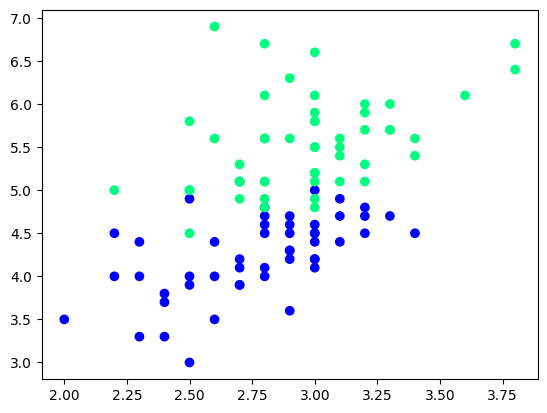

In [25]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['species'],cmap='winter')

In [26]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal width (cm),petal length (cm),species
82,2.7,3.9,1
89,2.5,4.0,1
52,3.1,4.9,1
73,2.8,4.7,1
62,2.2,4.0,1
80,2.4,3.8,1
59,2.7,3.9,1
85,3.4,4.5,1
95,3.0,4.2,1
51,3.2,4.5,1


In [27]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [28]:
df_train

,sepal width (cm),petal length (cm),species
113,2.5,5.0,2
115,3.2,5.3,2
80,2.4,3.8,1
97,2.9,4.3,1
75,3.0,4.4,1
70,3.2,4.8,1
86,3.1,4.7,1
50,3.2,4.7,1
66,3.0,4.5,1
143,3.2,5.9,2


In [29]:
df_val

,sepal width (cm),petal length (cm),species
110,3.2,5.1,2
117,3.8,6.7,2
121,2.8,4.9,2
148,3.4,5.4,2
91,3.0,4.6,1


In [30]:
df_test

,sepal width (cm),petal length (cm),species
94,2.7,4.2,1
81,2.4,3.7,1
73,2.8,4.7,1
90,2.6,4.4,1
93,2.3,3.3,1


In [31]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [32]:
y_test

array([2, 2, 2, 2, 1])

Case 1 - Bagging

In [33]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
115,3.2,5.3,2
115,3.2,5.3,2
143,3.2,5.9,2
75,3.0,4.4,1
86,3.1,4.7,1
115,3.2,5.3,2
70,3.2,4.8,1
115,3.2,5.3,2


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [35]:
dt_bag1 = DecisionTreeClassifier()

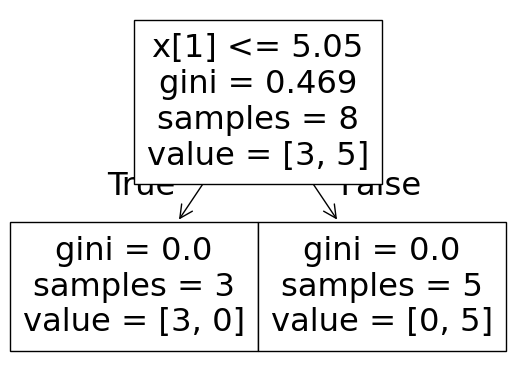

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


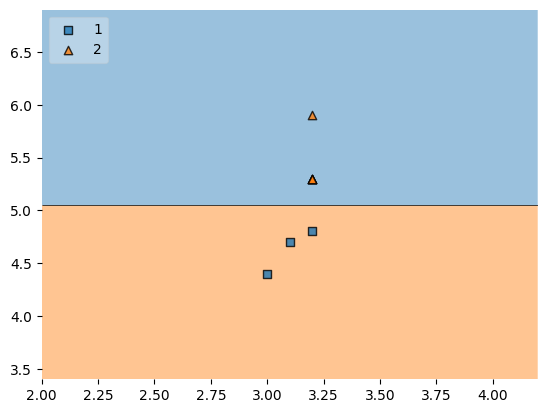

In [37]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

evaluate(dt_bag1,X,y)

In [38]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),species
97,2.9,4.3,1
75,3.0,4.4,1
80,2.4,3.8,1
70,3.2,4.8,1
143,3.2,5.9,2
70,3.2,4.8,1
97,2.9,4.3,1
115,3.2,5.3,2


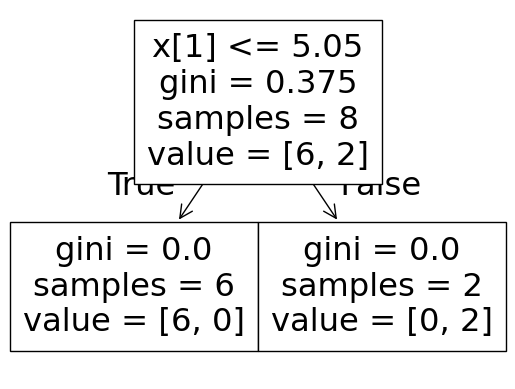

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


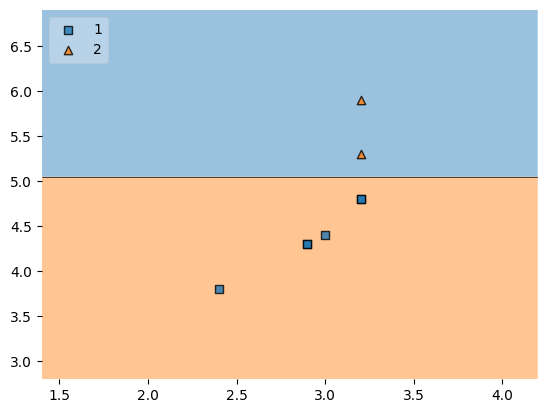

In [39]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [40]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),species
70,3.2,4.8,1
143,3.2,5.9,2
75,3.0,4.4,1
97,2.9,4.3,1
80,2.4,3.8,1
115,3.2,5.3,2
113,2.5,5.0,2
50,3.2,4.7,1


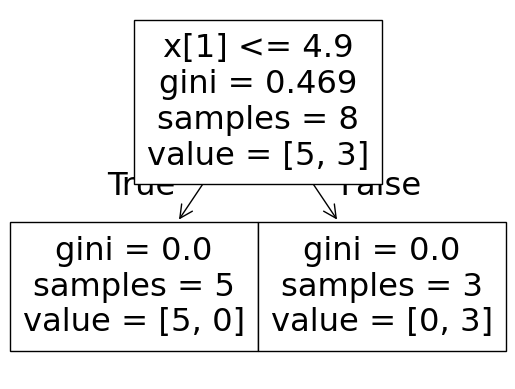

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


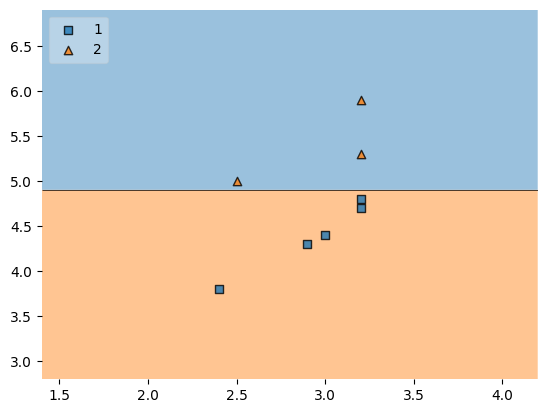

In [41]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [42]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))


Predict

In [43]:
df_test

,sepal width (cm),petal length (cm),species
94,2.7,4.2,1
81,2.4,3.7,1
73,2.8,4.7,1
90,2.6,4.4,1
93,2.3,3.3,1


In [44]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Pasting

In [45]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),species
113,2.5,5.0,2
115,3.2,5.3,2
80,2.4,3.8,1
97,2.9,4.3,1
75,3.0,4.4,1
70,3.2,4.8,1
86,3.1,4.7,1
50,3.2,4.7,1
66,3.0,4.5,1
143,3.2,5.9,2


In [46]:
df_train.sample(8)

,sepal width (cm),petal length (cm),species
97,2.9,4.3,1
115,3.2,5.3,2
66,3.0,4.5,1
86,3.1,4.7,1
113,2.5,5.0,2
75,3.0,4.4,1
80,2.4,3.8,1
50,3.2,4.7,1


Random Subspaces

In [49]:
df1 = df.sample(10)

In [50]:
df1

,sepal width (cm),petal length (cm),species
126,2.8,4.8,2
77,3.0,5.0,1
74,2.9,4.3,1
138,3.0,4.8,2
106,2.5,4.5,2
105,3.0,6.6,2
79,2.6,3.5,1
134,2.6,5.6,2
116,3.0,5.5,2
117,3.8,6.7,2


In [51]:
df1.sample(2,replace=True,axis=1)

,species,petal length (cm)
126,2,4.8
77,1,5.0
74,1,4.3
138,2,4.8
106,2,4.5
105,2,6.6
79,1,3.5
134,2,5.6
116,2,5.5
117,2,6.7


Random Patches

In [52]:
df1

,sepal width (cm),petal length (cm),species
126,2.8,4.8,2
77,3.0,5.0,1
74,2.9,4.3,1
138,3.0,4.8,2
106,2.5,4.5,2
105,3.0,6.6,2
79,2.6,3.5,1
134,2.6,5.6,2
116,3.0,5.5,2
117,3.8,6.7,2


In [53]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,species,sepal width (cm)
77,1,3.0
138,2,3.0
138,2,3.0
74,1,2.9
74,1,2.9
74,1,2.9
79,1,2.6
126,2,2.8
